<center>
    <h1>
    Preprocess - Étape 2
    </h1>
</center>

In [1]:
%%html

<!-- styles d'affichage -->
<style>
    .section_div {
        width:70%;
        height:1.5px;
        border:none;
        color:black;
        background-color:black;
        margin: auto;
        margin-top: 0px;
        margin-bottom: 0px;
    }

    .answer {
        color:blue;
    }

    .question {
        color:red;
    }

    .note {
        color:green;
        font-weight: bold;
    }
</style>

In [2]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [3]:
#
# import utilitaires
#
%matplotlib inline

import librosa as rosa
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm

In [4]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

# load dataset explore
explored_df = pd.read_csv(config.get_csv_filename(DatasetType.EXPLORED))

In [5]:
# validation des donnees explorees
print("Dataset shape:", explored_df.shape)

print()

print("Types")
display(explored_df.dtypes.to_frame().T)

print

print("Affichage succint")
display(explored_df.head())

Dataset shape: (1104, 6)

Types


,common_name,primary_label,latitude,longitude,filename,duration_ms
0,object,object,float64,float64,object,int64


Affichage succint


,common_name,primary_label,latitude,longitude,filename,duration_ms
0,Barn Swallow,barswa,54.5789,11.9284,barswa/XC208241.ogg,29936
1,Barn Swallow,barswa,30.5564,-96.4243,barswa/XC210730.ogg,55008
2,Barn Swallow,barswa,42.4822,24.3437,barswa/XC239627.ogg,63768
3,Barn Swallow,barswa,-32.8987,26.3775,barswa/XC252931.ogg,16367
4,Barn Swallow,barswa,32.7709,-108.2762,barswa/XC253252.ogg,16535


<div class="answer">

* Shape est telle qu'attendue void 00-jfgagnon-exploration.ipynb
* Types sont tels qu'attendus
* Les attributs sont tel qu'attendus.

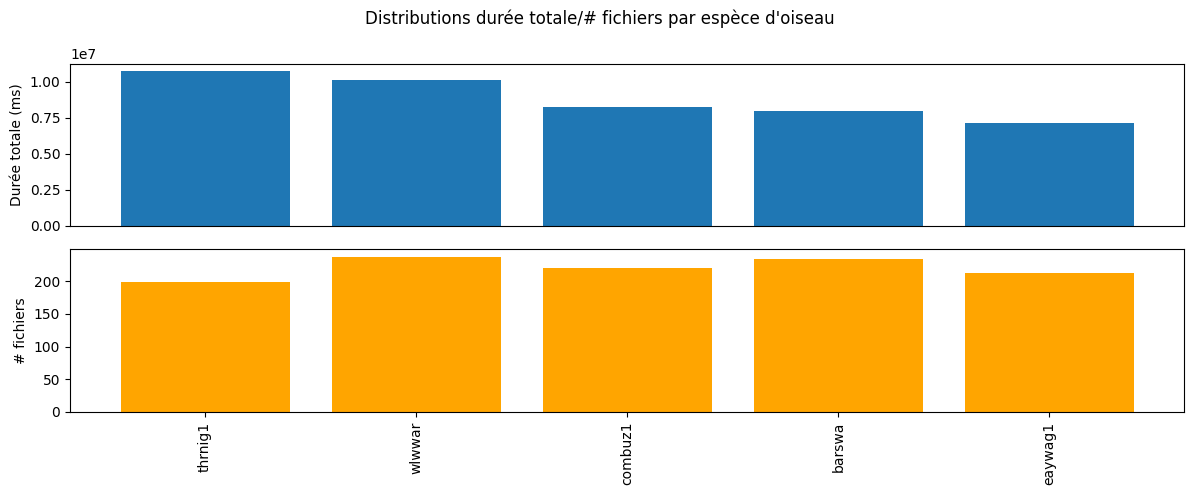


Statistique sommaire de 'duration_ms' pour toutes les espèces.


count       mean           std        min        25%  \
duration_ms sum      5.0  8837998.0  1.509263e+06  7165340.0  7946208.0   
            count    5.0      220.8  1.581771e+01      199.0      213.0   

                         50%         75%         max  
duration_ms sum    8242555.0  10125187.0  10710700.0  
            count      220.0       235.0       237.0

In [6]:
# regarder nombre de fichiers et duree total par espece
#
groups = explored_df[["primary_label", "duration_ms"]] \
                    .groupby(by="primary_label")
aggregate = groups.agg({"duration_ms": ["sum", "count"]}) \
                  .sort_values(by=("duration_ms", "sum"), ascending=False)
aggregate_count = len(aggregate)

total_duration = aggregate[("duration_ms", "sum")]
num_samples = aggregate[("duration_ms", "count")]

STEP = 1
WIDTH = 2

dist_range = range(aggregate_count)
dist_range_step = range(0, aggregate_count, STEP)

indices = [i for i in dist_range]
indices_step = [i for i in dist_range_step]

plt.figure(figsize=(12, 5))

plt.subplot(211)
plt.bar(indices,
        total_duration.iloc[indices])
plt.ylabel("Durée totale (ms)")
plt.tick_params(axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False)

plt.subplot(212)
plt.bar(indices,
        num_samples.iloc[indices],
        color="orange")
plt.ylabel("# fichiers")

plt.gca().set_xticks(indices_step)
plt.gca().set_xticklabels([aggregate.index[i] for i in indices_step], rotation=90)

plt.suptitle("Distributions durée totale/# fichiers par espèce d'oiseau")
plt.tight_layout()
plt.show()

print()

print("Statistique sommaire de 'duration_ms' pour toutes les espèces.")
display( aggregate.describe().T )

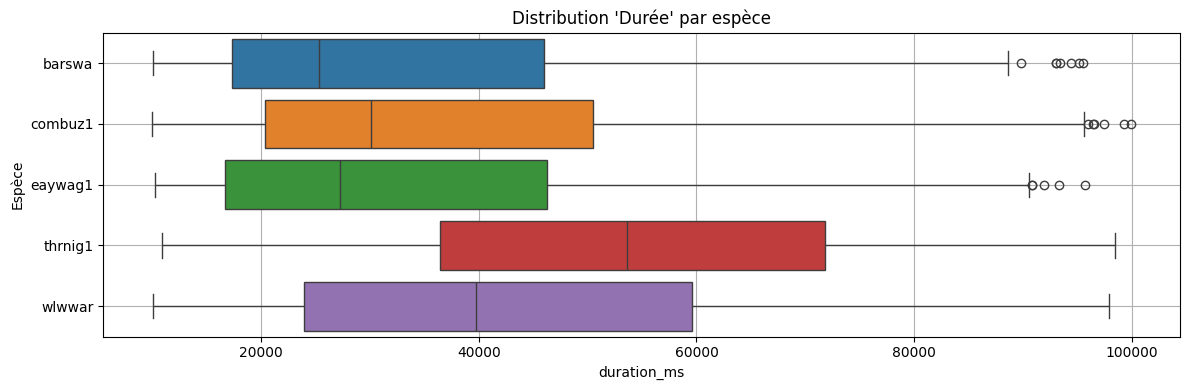

In [7]:
# regarder distribution de la duree par espece
#
duration_dict = {}

species = list(groups.groups.keys())

for i in indices_step:
    primary_label = species[i]
    duration_dict[primary_label] = groups.get_group(primary_label)["duration_ms"]

plt.figure(figsize=(12, 4))
sns.boxplot(duration_dict, orient="h", ax=plt.gca())
plt.grid()
plt.title("Distribution 'Durée' par espèce")
plt.xlabel("duration_ms")
plt.ylabel("Espèce")

plt.tight_layout()
plt.show()

<div class="answer">

* 5 espèces tel qu'attendu.
* Les distribution ne sont pas balancées (telles qu'attendues).

Basé sur les recherches faite dans la littérature, le pipeline d'entraînement devra accepter les données sous cette forme:

<div align="center">
  <img src="img/classification-pipeline.png" width=512>
</div>

Le fichier audio source est découpé en segments d'une durée D secondes. Les caractéristiques de chaque segment sont extraites à l'aide du mel-spectrogram. Celui-ci s'apparente à une image de W mel-bands x H frame x 1 canal. Les caractéristiques de S segments consécutifs seront regroupées pour effectuer la classification. Ce regroupement est nécessaire dû à la nature de nos données. En effet, le label est connu pour chaque fichier et non pour chaque segment. C'est le weak-labeling et la technique d'apprentissage qui l'adresse se nomme multiple instance learning.

Noter que les segments peuvent se chevaucher (et le seront) comme l'illustre la figure suivante:

<div align="center">
  <img src="img/segments.png" width=512>
</div>

Le problème de classification audio est maintenant un problème de vision par ordinateur. Nous dénoterons S segments consécutifs par groupe. On cherche donc une façon de resampler les données en groupes de tel sorte qu'elles couvrent l'ensemble des données originales mais aussi résulte en un nouvel ensemble de données balancées.

Basé sur les recherches faite dans la littérature, un segment de 3 secondes est un bon point de départ pour les chants d'oiseaux. En assumant qu'un groupe à une durée de 6 secondes (correspond à 3 segments de 3s avec overlap de 50%) nous pouvons continuer l'analyse pour identifier le nombres de samples par espèces. L'objectif est de "couvrir" tous les fichiers audio (pour avoir une plus grande diversité auditive) sans trop d'overlap entre les groupes (répétition de samples).

Durée d'un groupe
$$
    \begin{align}
        Duration_{groupe} &= (1 - \%_{overlap}) Duration_{segment} (S - 1) + Duration_{segment} \\
        &= Duration_{segment} \left[   (1 - \%_{overlap}) (S - 1) + 1 \right] \\
    \end{align}
$$

In [8]:
# choisir caracteristiques de groupes
#
SEGMENT_COUNT = 3
SEGMENT_DURATION = 3_000 # doit être en ms
SEGMENT_OVERLAP = 0.5

def group_duration():
    return SEGMENT_DURATION * ( (1.0 - SEGMENT_OVERLAP) * (SEGMENT_COUNT - 1) + 1)

def non_overlaping_group_count(duration, group_duration):
    return math.floor(duration / group_duration)

stats = aggregate[("duration_ms", "sum")].describe().iloc[2:]
stats.name = "durée totale (ms)/espèce"

stats2 = aggregate[("duration_ms", "count")].describe().iloc[2:]
stats2.name = "# éléments/espèce"

stats_group = stats.apply( non_overlaping_group_count, args=(group_duration(),))
stats_group.name = "# groupes/espèce"

stats_group2 = stats_group * aggregate_count
stats_group2.name = "# groupes total pour datset"

stats_df = pd.concat([stats2, stats, stats_group, stats_group2], axis=1)

print("# espèces:", aggregate_count)
print()
print("Durée groupe:", group_duration(), "(ms)")
print("Durée segment:", SEGMENT_DURATION, "(ms) - # segments:", SEGMENT_COUNT, "- overlap:", SEGMENT_OVERLAP)

print()

print("Quantité de groupes selon stats")
display(stats_df.T)

# espèces: 5

Durée groupe: 6000.0 (ms)
Durée segment: 3000 (ms) - # segments: 3 - overlap: 0.5

Quantité de groupes selon stats


,std,min,25%,50%,75%,max
# éléments/espèce,1.581771e+01,199.0,213.0,220.0,235.0,237.0
durée totale (ms)/espèce,1.509263e+06,7165340.0,7946208.0,8242555.0,10125187.0,10710700.0
# groupes/espèce,2.510000e+02,1194.0,1324.0,1373.0,1687.0,1785.0
# groupes total pour datset,1.255000e+03,5970.0,6620.0,6865.0,8435.0,8925.0


<div class="answer">

* En se basant sur la médiane, ~1372 groupes de 6 secondes feraient en sorte que ~50 % des espèces seraient suréchantillonnées et ~50 % seraient sous-échantillonnées. Cela nous apparaît comme un bon équilibre.

<div class="answer">

Chaque espèce est constitué d'un nombre variable de fichiers ayant lui-même une durée variable. Le contrôle de la couverture de l'échantillonmemnt nous apparait important pour assurer une bonne représentatitivité des données. Pour ce faire, nous allons utiliser les séquences d'Halton. Elles ont comme avantages d'être déterministe, simple d'implémentation, de contrôler précisément la quantité d'échantillons voulus et de bien couvrir l'espace d'échantillonement. Voir [Wikipedia](https://en.wikipedia.org/wiki/Halton_sequence) pour plus de détails.

Dans un but d'efficacité, les mel-spectrograms seront calculés 1 seul fois pour chaque fichier audio. L'alternative serait de le faire pour chaque segment lors de l'entraînement. Ceci nous semble très demandant car chaque segment est visité plusieurs fois et le calcul est couteux.

Finalement, dans un but d'économiser l'espace disque, le format HDFS est utilisé. Les mel-spectrograms auront leurs clefs et les groupes seront des vues.

En résumé, le preprocess fera:
1. Calculer le mel-spectrogram de tous les fichier audio au complet
2. Mettre information de durée par espece ; comme si c'était 1 seul grand fichier
3. Avec la séquence d'Halton, on sample un start de groupe ; ce start est remappé sur la bonne partie du bon fichier avec l'info trouvée en 2.